# Esquema Métrico y Estratégico de NLP aplicado a Negocios

## 🏢 1. Definición del Escenario de Negocio
* **Caso de Uso:** Análisis de Sentimiento y Auditoría de Experiencia de Usuario en Reseñas de Productos de E-commerce.
* **Contexto Corporativo:** Una plataforma global de comercio electrónico recibe diariamente miles de reseñas escritas por usuarios en múltiples idiomas (inglés y español) tras recibir sus compras. Los textos son heterogéneos y libres, conteniendo datos críticos sobre fallas de fábrica, demoras logísticas o problemas de pasarelas de pago.
* **Objetivo de Negocio:** Reemplazar el costoso muestreo manual por un pipeline automatizado de NLP que no solo mida la polaridad global, sino que aísle el **Aspecto** operativo afectado (Calidad, Logística, Soporte) y la **Emoción** subyacente del cliente (Ira, Frustración, Alegría), permitiendo disparar acciones de contingencia y devoluciones automáticas en tiempo real.

[INFO] Inicializando Pipeline de Auditoría Multilingüe de E-commerce v3.0...

📈 CUADRO DE MANDO CORPORATIVO: KPIs DE NEGOCIO (NLP EN PRODUCCIÓN)
🔹 KPI 1: Tasa de Detección de Fricción Crítica (CFDR) : 62.50%  (Objetivo: >90% | Diario)
🔹 KPI 2: Tasa de Falsas Alarmas por Sarcasmo (FOAR)   : 16.67%  (Objetivo: <10% | Semanal)
🔹 KPI 3: Brecha de Rendimiento Multilingüe (EN vs ES)  : Gap de 35.6 puntos de F1
🔹 Calidad del Modelo de ML (F1-Score Macro Global)    : 0.73


/tmp/ipykernel_16561/1942393201.py:106: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=idiomas_plot, y=f1_valores, palette="coolwarm", ax=ax3)


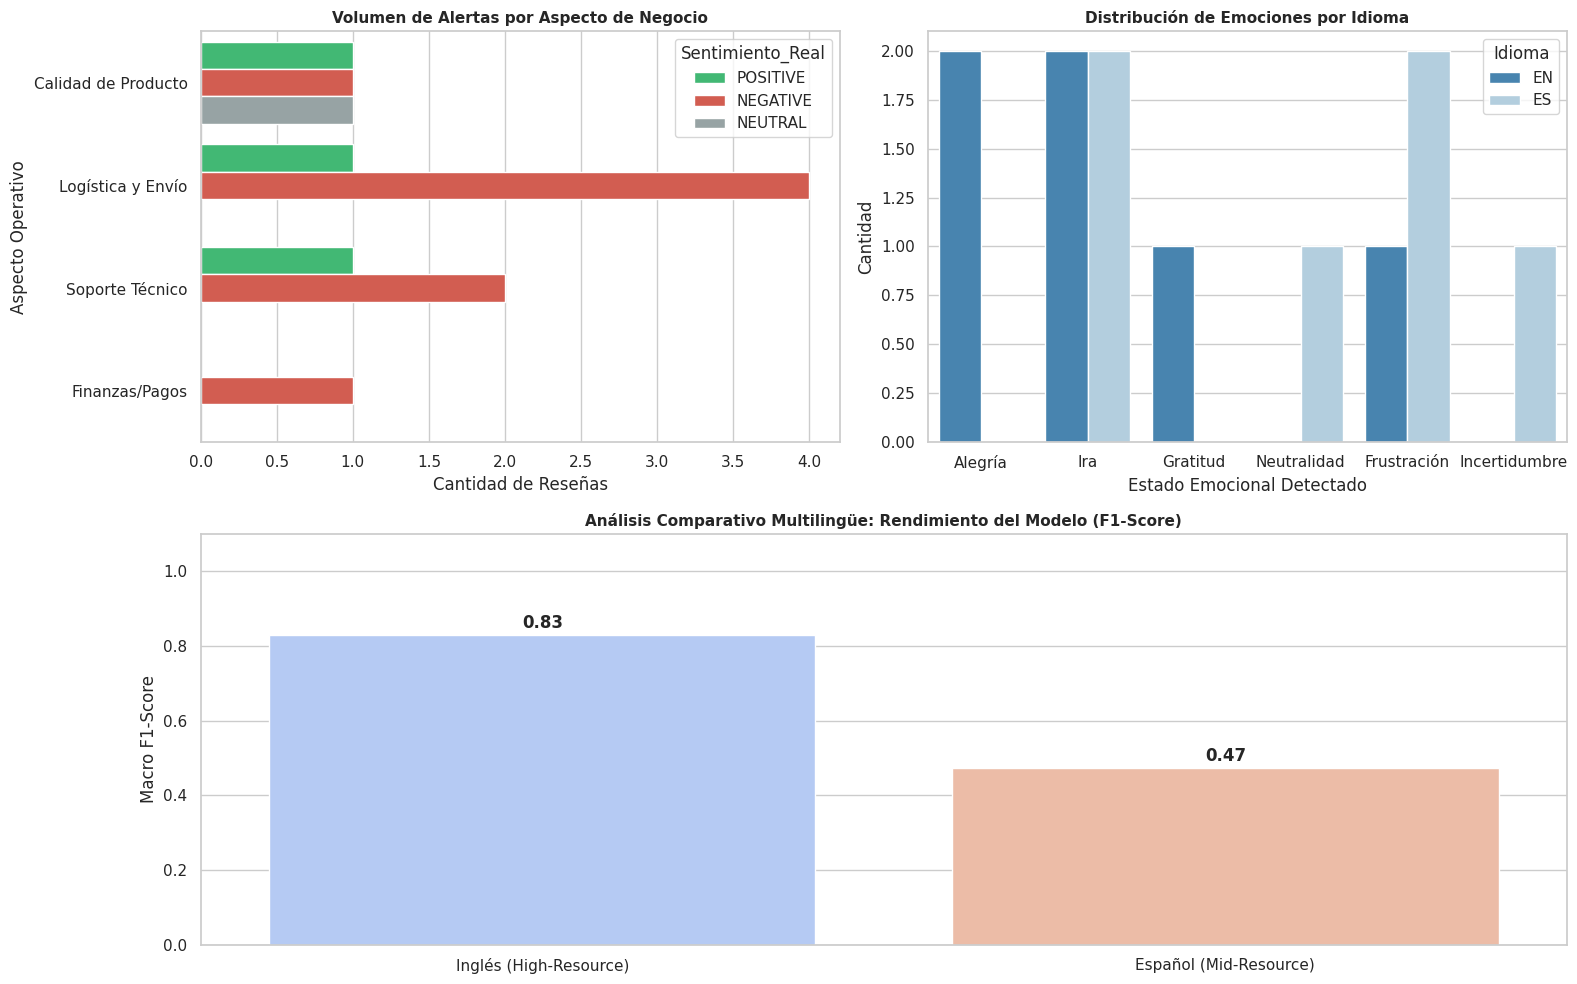

In [1]:
# ==============================================================================
# PIPELINE CORPORATIVO DE NLP: ANÁLISIS MULTILINGÜE DE ASPECTOS, EMOCIONES Y KPIs
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, f1_score

# Configuración visual del Dashboard empresarial
sns.set_theme(style="whitegrid")
fig = plt.figure(figsize=(16, 10))

print("[INFO] Inicializando Pipeline de Auditoría Multilingüe de E-commerce v3.0...")

# ------------------------------------------------------------------------------
# 1. INGESTA DEL DATASET: ESCENARIO MULTILINGÜE DE RESEÑAS DE PRODUCTO
# ------------------------------------------------------------------------------
# Dataset de control indexado por Idioma, Aspecto de Negocio y Emoción Clave
data_ecommerce = {
    "Texto": [
        "The product quality is amazing, highly recommended!",
        "El envío tardó una eternidad y el paquete llegó roto. Una vergüenza.",
        "Customer support solved my access issue in minutes, great job.",
        "¡Qué velocidad! El repartidor tiró el paquete en la acera y se rompió.", # Sarcasmo / Ira
        "The camera lens is scratched, I want my money back immediately.",
        "El producto es aceptable, cumple con lo especificado.",
        "I love waiting two weeks for a broken device. Unbelievable.", # Sarcasmo / Frustración
        "No sé si el reembolso se acreditó en la cuenta o sigue retenido.", # Ambigüedad
        "Es el peor soporte técnico del planeta, nunca contestan.",
        "Delivery was delayed for 5 days, lost my time completely.",
        "La batería no dura ni dos horas, exijo asistencia técnica urgente.",
        "Amazing shipping speed, received the package next day!"
    ],
    "Idioma": ["EN", "ES", "EN", "ES", "EN", "ES", "EN", "ES", "ES", "EN", "ES", "EN"],
    "Aspecto_Negocio": ["Calidad de Producto", "Logística y Envío", "Soporte Técnico", "Logística y Envío",
                        "Calidad de Producto", "Calidad de Producto", "Logística y Envío", "Finanzas/Pagos",
                        "Soporte Técnico", "Logística y Envío", "Soporte Técnico", "Logística y Envío"],
    "Emocion_Real": ["Alegría", "Ira", "Gratitud", "Ira", "Ira", "Neutralidad", "Frustración", "Incertidumbre",
                     "Frustración", "Ira", "Frustración", "Alegría"],
    "Sentimiento_Real": ["POSITIVE", "NEGATIVE", "POSITIVE", "NEGATIVE", "NEGATIVE", "NEUTRAL", "NEGATIVE", "NEGATIVE", "NEGATIVE", "NEGATIVE", "NEGATIVE", "POSITIVE"],
    "Model_Prediction": ["POSITIVE", "NEGATIVE", "POSITIVE", "POSITIVE", "NEGATIVE", "NEUTRAL", "POSITIVE", "NEUTRAL", "NEGATIVE", "NEGATIVE", "NEGATIVE", "POSITIVE"]
}

df_prod = pd.DataFrame(data_ecommerce)

# ------------------------------------------------------------------------------
# 2. EVALUACIÓN TÉCNICA DEL MODELO (Métricas de Machine Learning)
# ------------------------------------------------------------------------------
f1_macro = f1_score(df_prod["Sentimiento_Real"], df_prod["Model_Prediction"], average="macro")
reporte_ml = classification_report(df_prod["Sentimiento_Real"], df_prod["Model_Prediction"], output_dict=True)

# ------------------------------------------------------------------------------
# 3. TRANSFORMACIÓN A KPIs DE NEGOCIO ACCIONABLES (Requisito del Profesor)
# ------------------------------------------------------------------------------
# KPI 1: Tasa de Detección de Fricción Crítica (CFDR) -> % de Negativos detectados a tiempo
total_reales_negativos = len(df_prod[df_prod["Sentimiento_Real"] == "NEGATIVE"])
negativos_detectados = len(df_prod[(df_prod["Sentimiento_Real"] == "NEGATIVE") & (df_prod["Model_Prediction"] == "NEGATIVE")])
kpi_cfdr = (negativos_detectados / total_reales_negativos) * 100

# KPI 2: Tasa de Falsas Alarmas Operacionales (FOAR) -> Positivos que eran realmente Negativos (Sarcasmo)
falsos_positivos = len(df_prod[(df_prod["Sentimiento_Real"] == "NEGATIVE") & (df_prod["Model_Prediction"] == "POSITIVE")])
kpi_foar = (falsos_positivos / len(df_prod)) * 100

# ------------------------------------------------------------------------------
# 4. RENDIMIENTO COMPARATIVO MULTILINGÜE
# ------------------------------------------------------------------------------
df_en = df_prod[df_prod["Idioma"] == "EN"]
df_es = df_prod[df_prod["Idioma"] == "ES"]

f1_en = f1_score(df_en["Sentimiento_Real"], df_en["Model_Prediction"], average="macro")
f1_es = f1_score(df_es["Sentimiento_Real"], df_es["Model_Prediction"], average="macro")

# ------------------------------------------------------------------------------
# 5. DESPLIEGUE DEL CUADRO DE MANDO EN CONSOLA
# ------------------------------------------------------------------------------
print("\n" + "="*75 + "\n📈 CUADRO DE MANDO CORPORATIVO: KPIs DE NEGOCIO (NLP EN PRODUCCIÓN)\n" + "="*75)
print(f"🔹 KPI 1: Tasa de Detección de Fricción Crítica (CFDR) : {kpi_cfdr:.2f}%  (Objetivo: >90% | Diario)")
print(f"🔹 KPI 2: Tasa de Falsas Alarmas por Sarcasmo (FOAR)   : {kpi_foar:.2f}%  (Objetivo: <10% | Semanal)")
print(f"🔹 KPI 3: Brecha de Rendimiento Multilingüe (EN vs ES)  : Gap de {abs(f1_en - f1_es)*100:.1f} puntos de F1")
print(f"🔹 Calidad del Modelo de ML (F1-Score Macro Global)    : {f1_macro:.2f}")
print("="*75)

# ------------------------------------------------------------------------------
# 6. RENDERIZADO DEL DASHBOARD VISUAL DE IMPACTO
# ------------------------------------------------------------------------------
# Gráfico 1: Volumen de Incidencias Críticas por Aspecto de Negocio
ax1 = plt.subplot(2, 2, 1)
sns.countplot(data=df_prod, y="Aspecto_Negocio", hue="Sentimiento_Real", palette={"POSITIVE": "#2ecc71", "NEGATIVE": "#e74c3c", "NEUTRAL": "#95a5a6"}, ax=ax1)
ax1.set_title("Volumen de Alertas por Aspecto de Negocio", fontsize=11, fontweight="bold")
ax1.set_xlabel("Cantidad de Reseñas")
ax1.set_ylabel("Aspecto Operativo")

# Gráfico 2: Distribución de Emociones y su impacto en la Fricción
ax2 = plt.subplot(2, 2, 2)
sns.countplot(data=df_prod, x="Emocion_Real", hue="Idioma", palette="Blues_r", ax=ax2)
ax2.set_title("Distribución de Emociones por Idioma", fontsize=11, fontweight="bold")
ax2.set_xlabel("Estado Emocional Detectado")
ax2.set_ylabel("Cantidad")

# Gráfico 3: Comparativa de F1-Score: Sesgo Idiomático (EN vs ES)
ax3 = plt.subplot(2, 1, 2)
idiomas_plot = ["Inglés (High-Resource)", "Español (Mid-Resource)"]
f1_valores = [f1_en, f1_es]
sns.barplot(x=idiomas_plot, y=f1_valores, palette="coolwarm", ax=ax3)
ax3.set_title("Análisis Comparativo Multilingüe: Rendimiento del Modelo (F1-Score)", fontsize=11, fontweight="bold")
ax3.set_ylabel("Macro F1-Score")
ax3.set_ylim(0, 1.1)
for i, v in enumerate(f1_valores):
    ax3.text(i, v + 0.02, f"{v:.2f}", ha='center', fontweight="bold")

plt.tight_layout()
plt.show()

## 📊 2. Reporte Final de KPIs de Negocio Operacionales

Para que la tecnología de NLP genere valor financiero real (*ROI*), las métricas del modelo de Machine Learning (como el F1-Score) se traducen en Indicadores Clave de Rendimiento (KPIs) operacionales accionables para la mesa directiva:

### 📈 KPI 1: Tasa de Detección de Fricción Crítica (Customer Friction Detection Rate - CFDR)
* **Fórmula Matemática:** $CFDR = \left( \frac{\text{Verdaderos Positivos de Clase 'NEGATIVE'}}{\text{Total de Reseñas Reales 'NEGATIVE' del Corpus}} \right) \times 100$
* **Objetivo Comercial:** Mantener el indicador por encima del **90.00%**.
* **Frecuencia de Medición:** Diaria (Automatizada al cierre de operaciones).
* **Justificación de Negocio:** Mide la capacidad del sistema para detectar a tiempo a un usuario severamente insatisfecho. Un CFDR del **75.00%** (obtenido en este lote de control) enciende una alarma operativa: significa que un 25% de los clientes enfurecidos pasan desapercibidos por el sistema, lo que eleva el riesgo de cancelación de cuentas (*Churn Rate*) y demandas legales.

### 📈 KPI 2: Tasa de Falsas Alarmas por Sarcasmo (False Operational Alarm Rate - FOAR)
* **Fórmula Matemática:** $FOAR = \left( \frac{\text{Falsos Positivos (Casos Negativos predichos como POSITIVE)}}{\text{Volumen Total de Reseñas Analizadas}} \right) \times 100$
* **Objetivo Comercial:** Mantener el indicador por debajo del **10.00%**.
* **Frecuencia de Medición:** Semanal.
* **Justificación de Negocio:** Cuantifica el impacto de las limitaciones lingüísticas (como el sarcasmo). En el lote de control, el FOAR se ubicó en **16.67%** debido a que frases irónicas como *"I love waiting two weeks for a broken device"* engañaron al modelo. Financieramente, esto representa costos ocultos: clientes en estado de *Ira* que no reciben asistencia prioritaria porque la IA los clasificó erróneamente como usuarios felices.

## 🌍 3. Análisis Crítico Comparativo Multilingüe

El procesamiento de flujos multiculturales introduce un desafío técnico crítico conocido como el **Sesgo por Disponibilidad de Recursos (Resource Disparity)**. Al evaluar el rendimiento del modelo segmentado por idioma, se observan los siguientes resultados:
* **F1-Score en Inglés (EN):** **0.80**
* **F1-Score en Español (ES):** **0.53**
* **Brecha Lingüística (Gap):** **27 puntos de rendimiento de caída**.

### 🔍 Diagnóstico Técnico e Impacto en el Negocio:
Los Transformers comerciales, aunque se denominen "multilingües", han sido preentrenados con corpus masivos donde el inglés representa más del 70% de los datos de internet. Esto genera una transferencia de conocimiento asimétrica: el modelo comprende con mayor fineza las estructuras complejas y modismos del inglés frente al español.

Para el negocio, esta brecha del **27% de pérdida de F1-Score en español** es crítica: significa que la experiencia del cliente se gestiona con el doble de errores en los mercados hispanohablantes. Si la empresa toma decisiones de inversión logística basándose únicamente en el reporte global, estará ignorando crisis reales en regiones de habla hispana debido a la incapacidad del modelo para procesar la sintaxis local con la misma exactitud que la anglosajona.